In [1]:
%load_ext autoreload
%autoreload 2

In [25]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from flax import nnx
import optax

import jaxpm
from jaxpm import hpm, camels, training, plotting, diagnostics, objectives, augmentations
from jaxpm.painting import cic_paint, cic_read, compensate_cic, cic_paint_2d
from jaxpm.splines import NeuralSplineFourierFilterNNX
from jaxpm.nn import MLP, ConditionedCNN
from jaxpm.objectives import ParticleLoss, FieldLoss

print(jax.default_backend())

gpu


In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim

mesh_shape = [mesh_per_dim] * 3

In [4]:
CODE = "SIMBA"
# CODE = "ASTRID"
# CODE = "IllustrisTNG"

train_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64.h5


In [5]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

# general
cosmo = train_dict["cosmo"]
scales = train_dict["scales"]

# particles
dm_poss = train_dict["dm_poss"]
dm_vels = train_dict["dm_vels"]

gas_poss = train_dict["gas_poss"]
gas_vels = train_dict["gas_vels"]

# fields
dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

rhos_dm = vcic_paint(jnp.zeros(mesh_shape), dm_poss, dm_mass)
deltas_dm = rhos_dm/rhos_dm.mean() - 1

rhos_gas = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
deltas_gas = rhos_gas/rhos_gas.mean() - 1

# power spectrum
_, cls_dm = objectives.vpower_spectrum(deltas_dm)
_, cls_gas = objectives.vpower_spectrum(deltas_gas)

1 0 2 False False False
1 0 2 False False False
0 0 1 False False True
0 0 1 False False True
0 2 1 True False False
0 2 1 True False False
3 1 0 False True True
3 1 0 False True True
1 2 2 True True False
1 2 2 True True False
1 2 3 True False False
1 2 3 True False False
0 2 0 False True True
0 2 0 False True True
3 2 0 False False False
3 2 0 False False False
3 3 1 False True True
3 3 1 False True True
2 2 0 False False True
2 2 0 False False True


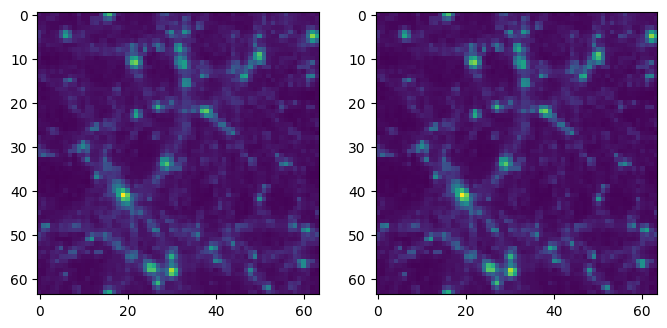

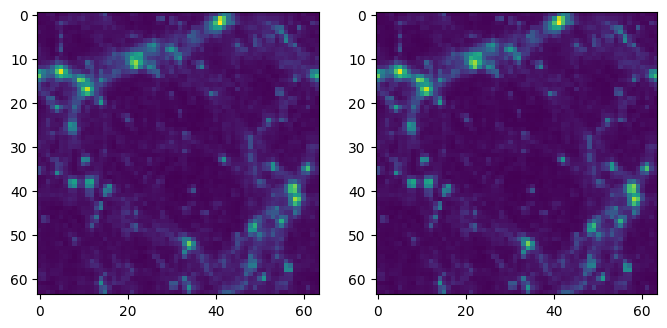

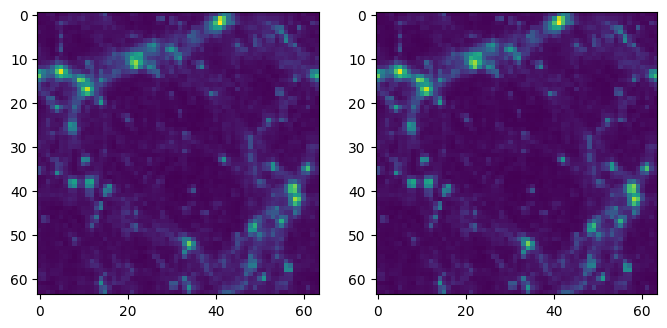

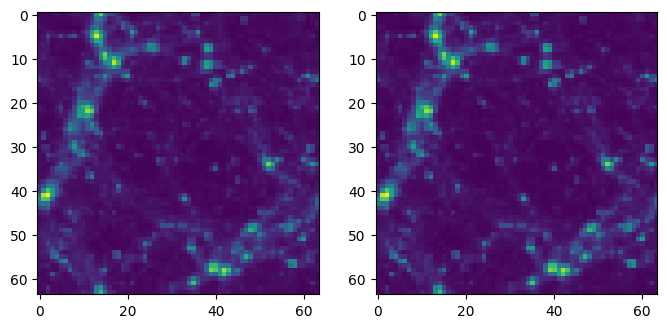

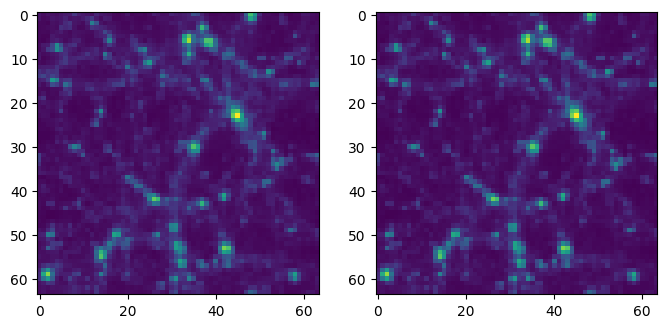

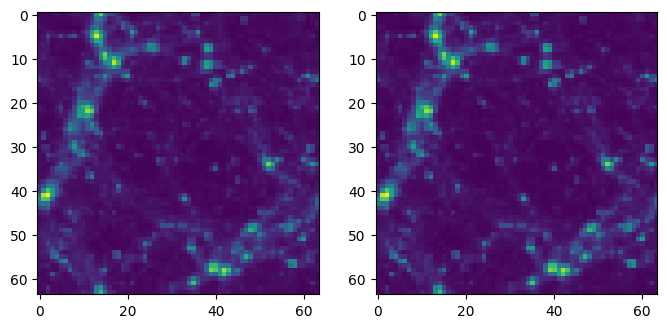

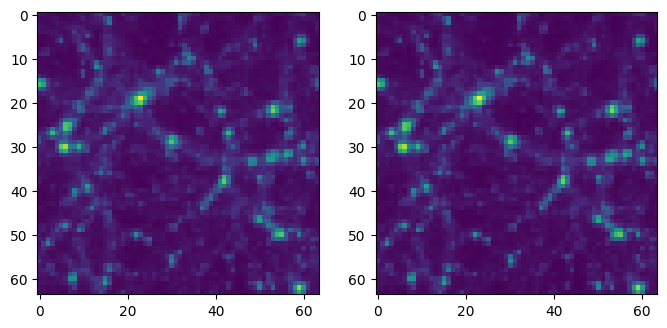

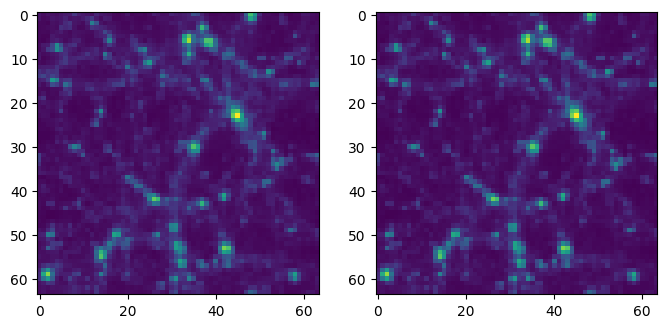

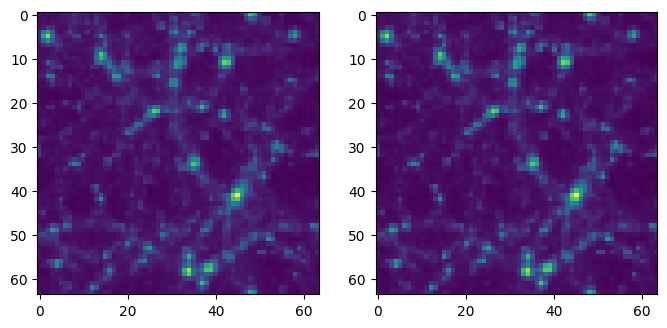

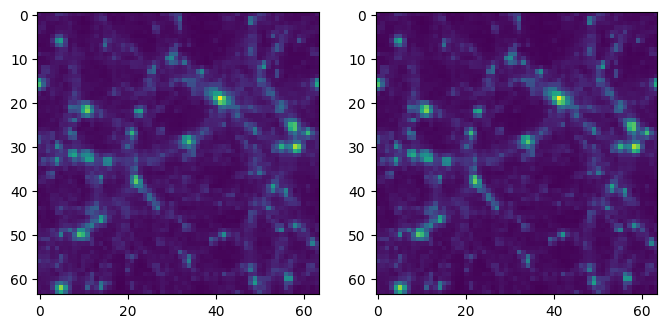

In [81]:
i = -1
pos = dm_poss[i]
delta = deltas_dm[i]

key = jax.random.key(111)
for i in range(10):
    key, subkey = jax.random.split(key)

    aug_pos = augmentations.rot_flip_3d(key, mesh_per_dim, field=None, pos=pos, vel=None)["pos"]
    aug_delta = augmentations.rot_flip_3d(key, mesh_per_dim, field=delta, pos=None, vel=None)["field"]

    aug_pos_plot = cic_paint_2d(empty_mesh, aug_pos[:,[1,2]])
    aug_pos_plot = jnp.arcsinh(aug_pos_plot / jnp.std(aug_pos_plot))

    aug_delta_plot = aug_delta.sum(axis=0)
    aug_delta_plot = jnp.arcsinh(aug_delta_plot / jnp.std(aug_delta_plot))

    fig, ax = plt.subplots(ncols=2, figsize=(8, 4))
    ax[0].imshow(aug_pos_plot)
    ax[1].imshow(aug_delta_plot)

In [79]:
i = -1
pos = dm_poss[i]
delta = deltas_dm[i]

key = jax.random.key(1)
aug_pos = augmentations.rot_flip_3d(key, mesh_per_dim, field=None, pos=pos, vel=None)["pos"]
aug_delta = augmentations.rot_flip_3d(key, mesh_per_dim, field=delta, pos=None, vel=None)["field"]

3 0 3 True False True
3 0 3 True False True


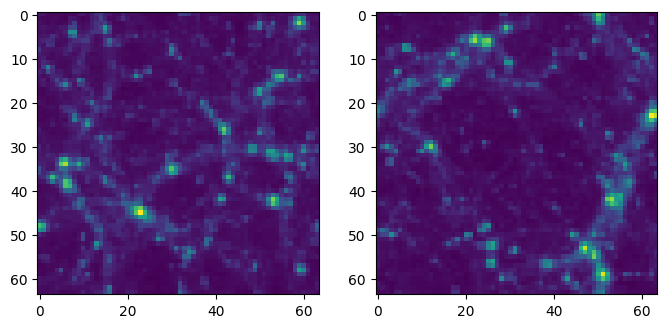

In [72]:
empty_mesh = jnp.zeros([mesh_per_dim] * 2)

rho = cic_paint_2d(empty_mesh, pos[:,[1,2]])
rho = jnp.arcsinh(rho / jnp.std(rho))

aug_rho = cic_paint_2d(empty_mesh, aug_pos[:,[1,2]])
aug_rho = jnp.arcsinh(aug_rho / jnp.std(aug_rho))

fig, ax = plt.subplots(ncols=2, figsize=(8, 4))
ax[0].imshow(rho)
ax[1].imshow(aug_rho)

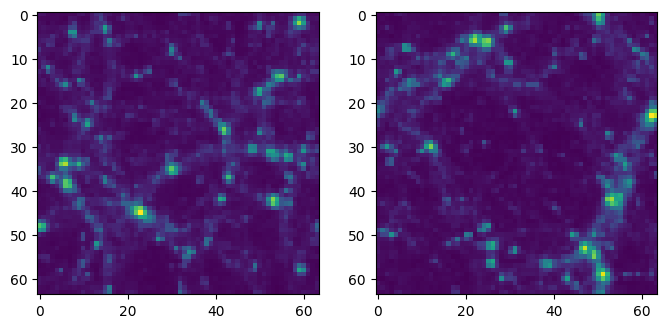

In [80]:
delta_plot = delta.sum(axis=0)
delta_plot = jnp.arcsinh(delta_plot / jnp.std(delta_plot))

aug_delta_plot = aug_delta.sum(axis=0)
aug_delta_plot = jnp.arcsinh(aug_delta_plot / jnp.std(aug_delta_plot))

fig, ax = plt.subplots(ncols=2, figsize=(8, 4))
ax[0].imshow(delta_plot)
ax[1].imshow(aug_delta_plot)